# Экзамен

### №1

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {plt}")
print("Все загружено")

Pandas version: 2.2.2
Numpy version: 2.0.2
Matplotlib version: <module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>
Все загружено


In [82]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
print("Все загружено")

Все загружено


In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
print("Все загружено")

Все загружено


**Игнорирование предупреждений**

In [84]:
import warnings
warnings.filterwarnings('ignore')
print("Успешно")

Успешно


### №2

In [85]:
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df_path = "/content/drive/MyDrive/Colab Notebooks/Third semester/Final Exam/data/pima-indians-diabetes.data.csv"

df = pd.read_csv(df_path, names=names)
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [86]:
df.sample(5)

,preg,plas,pres,skin,test,mass,pedi,age,class
378,4,156,75,0,0,48.3,0.238,32,1
204,6,103,72,32,190,37.7,0.324,55,0
506,0,180,90,26,90,36.5,0.314,35,1
77,5,95,72,33,0,37.7,0.370,27,0
315,2,112,68,22,94,34.1,0.315,26,0


### №3

In [87]:
df.shape

(768, 9)

### №4

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Таблица из 768 строк и 9 столбцов**

**Технических пропусков нет**

**Только числа: 7 целочисленные значения _(int)_ и два значения с плавающей точкой _(float)_**


In [89]:
df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Таблица медицинских данных с пациентами в возрасте от 21 до 81 года.

Среднее значение отклонения preg 3.369578

Среднее значение отклонения plas 31.972618

Среднее значение отклонения pres 69.105469

Среднее значение отклонения skin 20.536458

Среднее значение отклонения skin 79.799479

Среднее значение отклонения test 115.244002

Среднее значение отклонения mass 7.884160

Среднее значение отклонения pedi 0.331329

Среднее значение отклонения age 11.760232

Среднее значение отклонения class 0.476951

In [90]:
class_count = df.groupby('class').size()
class_count

,0
class,
0,500
1,268


**Данные являются неравномерными, один класс больше другого практически в два раза. Для более корректного обучения модели с данными необзодимо провести балансировку данных**

### 7

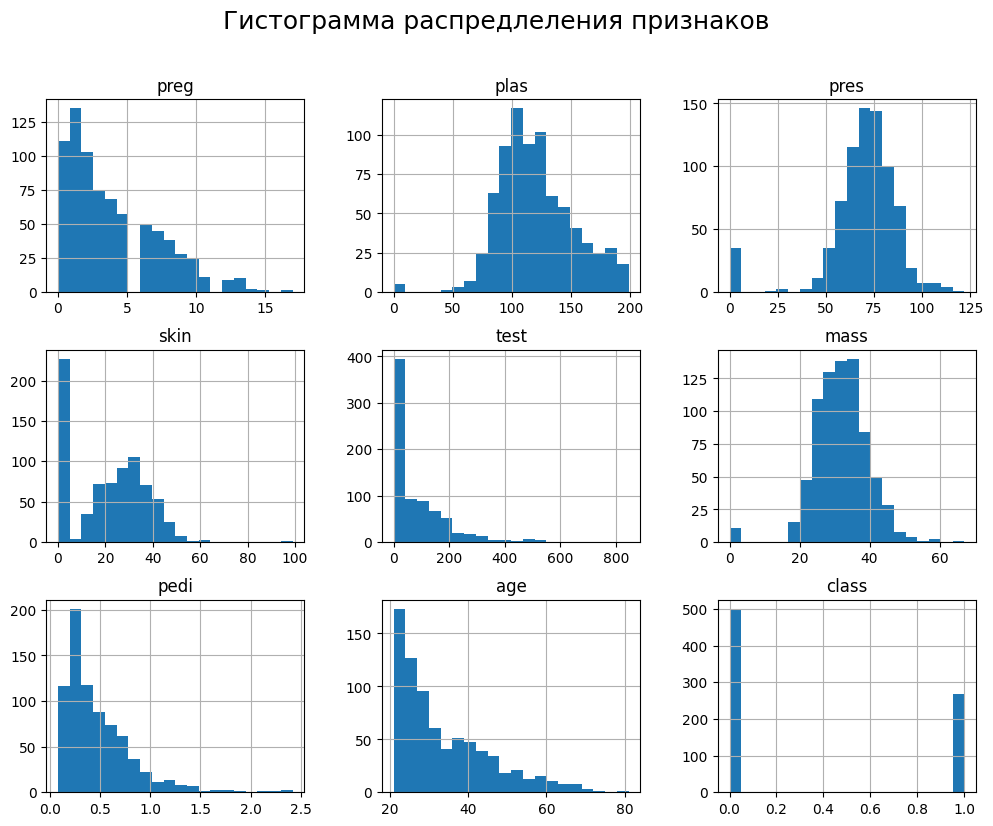

In [91]:
df.hist(figsize=(12, 9), bins=20)
plt.suptitle('Гистограмма распредлеления признаков', fontsize=18);

### 8

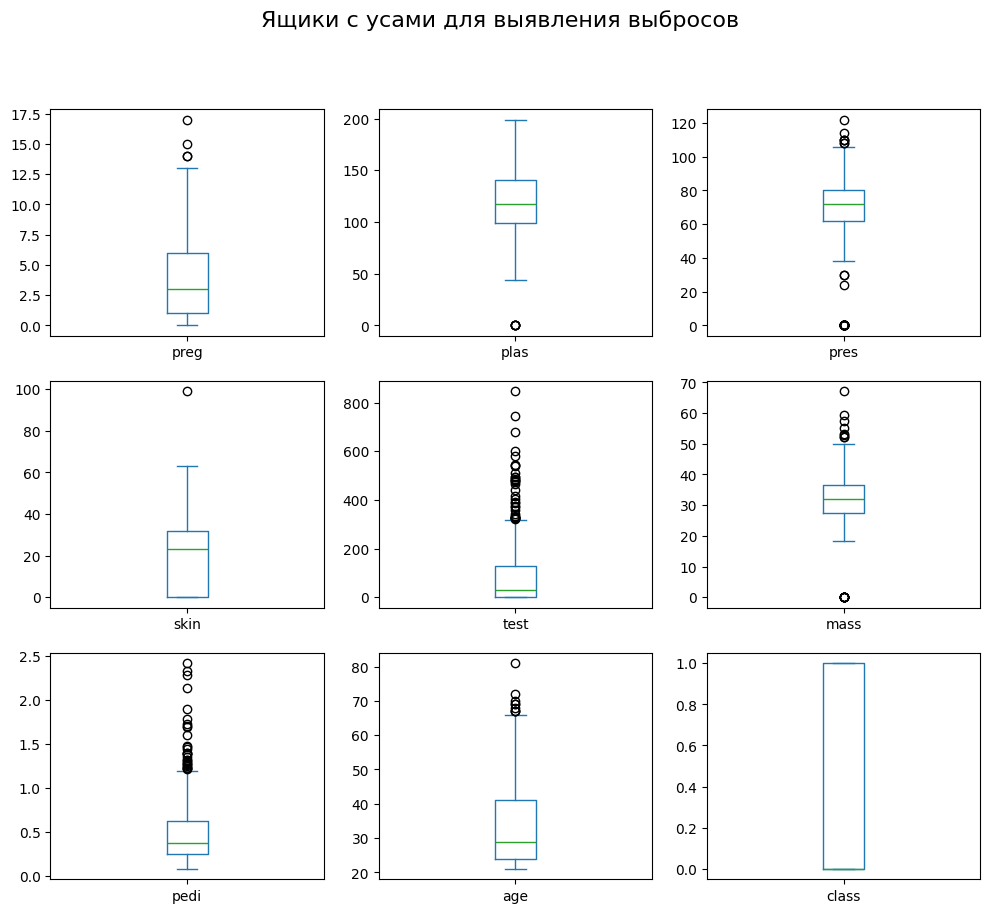

In [92]:
df.plot(kind='box', subplots=True, layout=(3,3), sharex=False, sharey=False, figsize=(12, 10))
plt.suptitle('Ящики с усами для выявления выбросов', fontsize=16)
plt.show()

Предполагается, что в предлагаемых данных есть значительное количество искусственных пропуско (заполненных нулей в выборке)
Точки в классах pass, press и mass находятся на нулевых значениях
Особое внимание к выбросам требуют классы test и pedi

### 9

In [93]:
array = df.values
array

array([[  6.   , 148.   ,  72.   , ...,   0.627,  50.   ,   1.   ],
       [  1.   ,  85.   ,  66.   , ...,   0.351,  31.   ,   0.   ],
       [  8.   , 183.   ,  64.   , ...,   0.672,  32.   ,   1.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,   0.245,  30.   ,   0.   ],
       [  1.   , 126.   ,  60.   , ...,   0.349,  47.   ,   1.   ],
       [  1.   ,  93.   ,  70.   , ...,   0.315,  23.   ,   0.   ]])

### 10

In [94]:
X = array[:, 0:8]
Y = array[:, 8]
print(f'X: {X[:5]}, Y: {Y[:5]}')

X: [[6.000e+00 1.480e+02 7.200e+01 3.500e+01 0.000e+00 3.360e+01 6.270e-01
  5.000e+01]
 [1.000e+00 8.500e+01 6.600e+01 2.900e+01 0.000e+00 2.660e+01 3.510e-01
  3.100e+01]
 [8.000e+00 1.830e+02 6.400e+01 0.000e+00 0.000e+00 2.330e+01 6.720e-01
  3.200e+01]
 [1.000e+00 8.900e+01 6.600e+01 2.300e+01 9.400e+01 2.810e+01 1.670e-01
  2.100e+01]
 [0.000e+00 1.370e+02 4.000e+01 3.500e+01 1.680e+02 4.310e+01 2.288e+00
  3.300e+01]], Y: [1. 0. 1. 0. 1.]


Код сработал корректно выделив все значения от целевой переменной

### 11

In [95]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=17)

### 12

In [96]:
models = []
models

[]

### 13

In [97]:
models.append(('LR', LogisticRegression(max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))
models

[('LR', LogisticRegression(max_iter=1000)),
 ('LDA', LinearDiscriminantAnalysis()),
 ('KNN', KNeighborsClassifier()),
 ('CART', DecisionTreeClassifier()),
 ('NB', GaussianNB()),
 ('SVM', SVC())]

### 14

In [98]:
results = []
names = []
scoring = 'accuracy'

print("Результаты оценки моделей (Кросс-валидация на обучающей выборке):")
for name, model in models:
    kfold = KFold(n_splits=10, random_state=17, shuffle=True)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name}: средняя точность = {cv_results.mean():.4f}, ст. отклонение = {cv_results.std():.4f}")

Результаты оценки моделей (Кросс-валидация на обучающей выборке):
LR: средняя точность = 0.7736, ст. отклонение = 0.0421
LDA: средняя точность = 0.7687, ст. отклонение = 0.0513
KNN: средняя точность = 0.6937, ст. отклонение = 0.0492
CART: средняя точность = 0.6956, ст. отклонение = 0.0528
NB: средняя точность = 0.7524, ст. отклонение = 0.0436
SVM: средняя точность = 0.7525, ст. отклонение = 0.0537


### 15

Лучший алгоритм модель **Логистическая регрессия**

**Наивысшая точность:** Модель **Логистическая регрессия** лучшая средняя доля верных ответов _(77.36%)_ среди всех

Высокая стабильность: У логистической низкое стандартное отклонение (0.0421). У  (LDA) точность ниже (0.7687)

Низкое стандартное отклонение логистической регрессии говорит о хорошей обобщающей способности и устойчивости

### 16

In [99]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

### 17

In [100]:
Y_pred = best_model.predict(X_test)
Y_pred

array([0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,
       0.])

### 22

In [101]:
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy на тестовой выборке: {accuracy:.4f}")

Accuracy на тестовой выборке: 0.7792


### 23

Матрица ошибок:
 [[89  8]
 [26 31]]


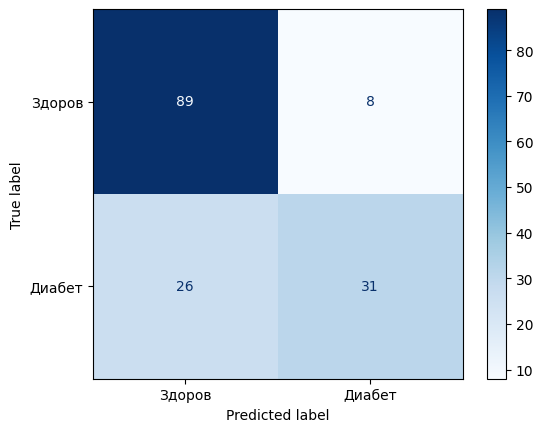

In [102]:
conf_matrix = confusion_matrix(Y_test, Y_pred)
classes = ['Здоров', 'Диабет']
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, values_format='d')
print("Матрица ошибок:\n", conf_matrix)

89 здоровых
31 с диабетом

8 ложноположительных срабатываний (здоровым назначили диагноз дибабет)

26 больных модель назвала здоровыми


### 24

In [103]:
print("Отчет о качестве классификации:")
print(classification_report(Y_test, Y_pred))

Отчет о качестве классификации:
              precision    recall  f1-score   support

         0.0       0.77      0.92      0.84        97
         1.0       0.79      0.54      0.65        57

    accuracy                           0.78       154
   macro avg       0.78      0.73      0.74       154
weighted avg       0.78      0.78      0.77       154



Точность - 0.79

Полнота - 0.54

F1 - 0.65

Полнота (recall) в 54% главный провал, на тестовой выборке модель определяла 54% от всех реальных больных

Модель имеет сильный перекос в сторону класса здоров. Модель не готова к использованию в реальной среде, что может носить высокие риски интеграции

### 25

In [104]:
level0 = [
    ('lr', LogisticRegression(max_iter=1000, random_state=17)),
    ('lda', LinearDiscriminantAnalysis()),
    ('svm', SVC(probability=True, random_state=17)),
    ('nb', GaussianNB())
]

In [105]:
level1 = LogisticRegression(max_iter=1000, random_state=17)

In [106]:
stacking_model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
stacking_model.fit(X_train, Y_train)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(max_iter=1000,
                                                   random_state=17)),
                               ('lda', LinearDiscriminantAnalysis()),
                               ('svm', SVC(probability=True, random_state=17)),
                               ('nb', GaussianNB())],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=17))

In [107]:
Y_pred_stacking = stacking_model.predict(X_test)

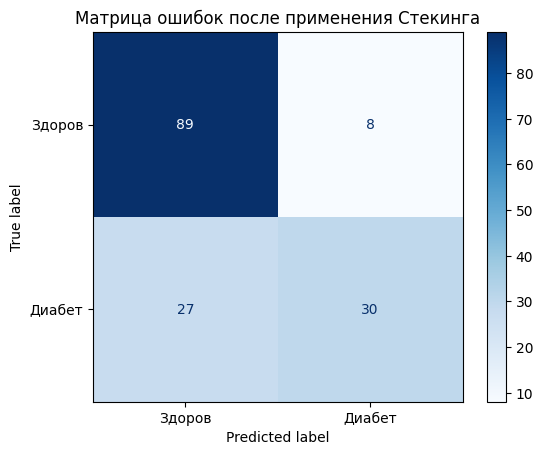

In [108]:
cm = confusion_matrix(Y_test, Y_pred_stacking)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Здоров', 'Диабет'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Матрица ошибок после применения Стекинга")
plt.show()

In [109]:
print("\n--- Результаты после применения Стекинга ---")
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_stacking):.4f}")
print("Матрица ошибок:\n", confusion_matrix(Y_test, Y_pred_stacking))
print("Отчет:\n", classification_report(Y_test, Y_pred_stacking))


--- Результаты после применения Стекинга ---
Accuracy: 0.7727
Матрица ошибок:
 [[89  8]
 [27 30]]
Отчет:
               precision    recall  f1-score   support

         0.0       0.77      0.92      0.84        97
         1.0       0.79      0.53      0.63        57

    accuracy                           0.77       154
   macro avg       0.78      0.72      0.73       154
weighted avg       0.78      0.77      0.76       154

